# Benchmark Workflow

This notebook prepares and analyzes the benchmark set used to compare calculated activation barriers against DLPNO-CCSD(T) reference values. The workflow is organized into benchmark-set selection, single-point input generation, energy collection, and performance plotting.


## Reviewer Run Tags

- `[REVIEWER-RUNNABLE]`: can be run from files included in this repository, such as CSV, descriptor pickle, ASE database, Parquet, or existing figure inputs. No raw Gaussian working directory is required.
- `[RAW-GAUSSIAN/E:/work]`: depends on raw calculation artifacts, Gaussian logs, Mol files, ORCA/Gaussian input-output folders, or the external raw calculation root configured by `BORYLXAT_RAW_CALC_ROOT` (default `E:/work/B_Cl_Nu`). These cells document provenance but are not required for routine review reruns.
- `[OPTIONAL-DESCRIPTOR-GENERATION]`: regenerates descriptors from the released database. Reviewers can skip it and use the pre-extracted descriptor pickle files to save time.


In [2]:
%load_ext autoreload
%autoreload 2


## Setup [REVIEWER-RUNNABLE]

This cell defines repository paths and the optional external benchmark workspace; it does not read raw calculation files by itself.


Project paths are centralized through `DFTStructureGenerator.project_paths`. Raw quantum-chemistry files are expected under `BORYLXAT_RAW_CALC_ROOT` or the default external calculation directory.


In [3]:
import glob
import os
import pickle
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from DFTStructureGenerator.project_paths import (
    CSV_DIR,
    FIGURE_DIR,
    TS_DATA_DIR,
    raw_calc_file,
    raw_calc_path,
)
from DFTStructureGenerator.thermochemistry import database_path, load_reaction_dataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

HARTREE_TO_KCAL = 627.5
BENCHMARK_DIR = raw_calc_path("Benchmark_new")
BENCHMARK_CSV_PATH = CSV_DIR / "Benchmark.csv"
BENCHMARK_RESULT_PATH = CSV_DIR / "Benchmark_Result.csv"
BENCHMARK_FIGURE_PATH = FIGURE_DIR / "FigureS17_Benchmark_MAE_R2_combined.png"


def benchmark_path(*parts):
    return BENCHMARK_DIR.joinpath(*parts)


def benchmark_file(*parts):
    return str(benchmark_path(*parts))


## Benchmark Set [REVIEWER-RUNNABLE]

Uses released CSV tables to define the benchmark subset.


The benchmark subset samples representative borane, Lewis-base, and chloride-substrate combinations. Duplicate Lewis-base atom ids are retained because those optimized reactant logs use Naid-specific filenames.


In [4]:
DUPLICATE_N_ID = [
    9, 43, 285, 310, 314, 345, 346, 347, 348, 349, 350, 351, 352,
    353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 372, 375, 376,
]

BENCHMARK_B_IDS = [388, 391, 394, 401, 427]
BENCHMARK_L_IDS = [1, 33, 46, 69, 72, 146]
BENCHMARK_CL_IDS = [443, 447, 475, 477, 490, 519, 506]

# Thermochemistry switch: revised benchmark annotations use QHARM by default.
USE_QHARM = True
DB_PATH = database_path(USE_QHARM)
BARRIER_COLUMN = "deltaGa_qharm(kcal/mol)" if USE_QHARM else "deltaGa(kcal/mol)"
reaction_df = load_reaction_dataset(
    TS_DATA_DIR / "Borane_all.csv", use_qharm=USE_QHARM, db_path=DB_PATH
)
print("Thermochemistry:", reaction_df.attrs["thermochemistry_source"])
print("Benchmark barrier column:", BARRIER_COLUMN)
cl_df = pd.read_csv(CSV_DIR / "reactants_Cl.csv")
borane_ligand_df = pd.read_csv(CSV_DIR / "reactants_B_N.csv")

benchmark_reaction_df = reaction_df.loc[
    np.isin(reaction_df["B_Index"], BENCHMARK_B_IDS)
    & np.isin(reaction_df["N_Index"], BENCHMARK_L_IDS)
    & np.isin(reaction_df["Cl_Index"], BENCHMARK_CL_IDS)
].copy()

benchmark_reaction_df[["B_Index", "N_Index", "Cl_Index", BARRIER_COLUMN]]


Thermochemistry: QHARM CSV columns (validated against database)
Benchmark barrier column: deltaGa_qharm(kcal/mol)


,B_Index,N_Index,Cl_Index,deltaGa_qharm(kcal/mol)
3,388,1,475,11.353407
5,388,1,477,10.896756
12,388,1,490,8.984941
19,388,1,506,10.521973
23,388,1,519,3.733998
152,388,69,490,15.267126
171,388,72,490,15.849619
173,388,72,519,9.467280
1117,391,33,477,16.825690
1118,391,33,519,7.512632


## Load Benchmark Structures [RAW-GAUSSIAN/E:/work]

Loads `calc_dict.pkl` from the external benchmark workspace. This file was prepared from optimized structures and is not needed if reviewers only inspect the curated benchmark CSV and final figure.


`calc_dict.pkl` stores the optimized benchmark geometries as `{name: [atom_symbols, coordinates, multiplicity]}`. Keeping this file as the structure source avoids relying on transient in-memory objects from database-building notebooks.


In [42]:
with open(benchmark_file("calc_dict.pkl"), "rb") as handle:
    calc_dict = pickle.load(handle)


## Method Definitions [REVIEWER-RUNNABLE]

Pure method metadata; no raw Gaussian/ORCA files are read here.


`METHOD_COLUMNS` defines the final comparison table. The M05-2X entries are helper calculations used only to add the SMD solvent correction to DLPNO-CCSD(T).


In [6]:
METHOD_COLUMNS = [
    "CAM-B3LYP-D3",
    "M062X-def2TZVP",
    "MN15L",
    "MN15",
    "PW6B95D3",
    "TPSS-D3",
    "TPSSh",
    "wB97M-V",
    "DLPNO",
    "wB97XD",
]

METHOD_LABELS = [
    "CAM-B3LYP-D3/6-311+G(d,p)",
    "M06-2X/def2-TZVP",
    "MN15-L/6-311+G(d,p)",
    "MN15/6-311+G(d,p)",
    "PW6B95-D3/6-311+G(d,p)",
    "TPSS-D3/6-311+G(d,p)",
    "TPSSh/6-311+G(d,p)",
    "ωB97M-V/def2-TZVPP",
    "DLPNO-CCSD(T)/cc-pVTZ",
    "ωB97X-D/6-311+G(d,p)",
]

DFT_METHODS = {
    "CAM-B3LYP-D3": "CAM-B3LYP/6-311+G(d,p) em=gd3bj SCRF=(smd,solvent=Toluene)",
    "M062X-def2TZVP": "M062X/def2TZVP SCRF=(smd,solvent=Toluene)",
    "MN15L": "MN15L/6-311+G(d,p) SCRF=(smd,solvent=Toluene)",
    "MN15": "MN15/6-311+G(d,p) SCRF=(smd,solvent=Toluene)",
    "PW6B95D3": "PW6B95D3/6-311+G(d,p) SCRF=(smd,solvent=Toluene)",
    "TPSS-D3": "TPSSTPSS/6-311+G(d,p) em=gd3bj SCRF=(smd,solvent=Toluene)",
    "TPSSh": "TPSSh/6-311+G(d,p) SCRF=(smd,solvent=Toluene)",
    "wB97XD": "wB97XD/6-311+G(d,p) SCRF=(smd,solvent=Toluene)",
    "M052X": "M052X/6-31G*",
    "M052X-SMD": "M052X/6-31G* SCRF=(smd,solvent=Toluene)",
}

ORCA_OUTPUT_FOLDERS = {
    "wB97M-V": "wB97M-V",
    "DLPNO": "DLPNO_new",
}
DLPNO_INPUT_FOLDER = "DLPNO"

assert len(METHOD_COLUMNS) == len(METHOD_LABELS)


## Prepare Single-Point Inputs [RAW-GAUSSIAN/E:/work]

Generates Gaussian/ORCA input files in the external benchmark workspace for rerunning quantum-chemical single-point calculations.


The next cells generate Gaussian and ORCA single-point inputs from the benchmark geometries. They are preparation cells and should be run before submitting the external quantum-chemistry jobs.


In [ ]:
from DFTStructureGenerator.FormatConverter import block_to_gjf

# Gaussian SPE inputs for the DFT benchmark methods and M05-2X correction jobs.
for method_name, route_section in DFT_METHODS.items():
    for structure_name, (atoms, positions, multiplicity) in calc_dict.items():
        block_to_gjf(
            atoms,
            positions,
            benchmark_file("SPE", f"{method_name}_{structure_name}.gjf"),
            method=route_section,
            multiplicity=multiplicity,
            charge=0,
        )


In [ ]:
# ORCA input for the ωB97M-V comparison.
for structure_name, (atoms, positions, multiplicity) in calc_dict.items():
    with open(benchmark_file("wB97M-V", f"wB97M-V_{structure_name}.inp"), "wt") as handle:
        handle.write("! wB97M-V def2-TZVPP RIJCOSX def2/J def2-TZVPP/C tightSCF noautostart defgrid3\n")
        handle.write(
            "%maxcore 2000\n%pal nprocs 32 end\n%scf\nMaxIter 500\nend\n\n"
            "%cpcm\nSMD true\nSMDsolvent \"Toluene\"\nend\n\n"
        )
        handle.write(f"* xyz 0 {multiplicity}\n")
        for atom, position in zip(atoms, positions):
            handle.write(f"{atom} {position[0]} {position[1]} {position[2]}\n")
        handle.write("*\n")


In [11]:
# ORCA input for DLPNO-CCSD(T). The submitted inputs are stored separately
# from the final output folder used during energy collection.
for structure_name, (atoms, positions, multiplicity) in calc_dict.items():
    with open(benchmark_file(DLPNO_INPUT_FOLDER, f"DLPNO_{structure_name}.inp"), "wt") as handle:
        handle.write("! DLPNO-CCSD(T) TightPNO RIJCOSX cc-pVTZ cc-pVTZ/C def2/J TightSCF noautostart miniprint nopop\n")
        handle.write("%maxcore 4000\n%pal nprocs 16 end\n\n")
        handle.write(f"* xyz 0 {multiplicity}\n")
        for atom, position in zip(atoms, positions):
            handle.write(f"{atom} {position[0]} {position[1]} {position[2]}\n")
        handle.write("*\n")


## Archive Optimized Geometries [RAW-GAUSSIAN/E:/work]

Copies optimized reactant/TS Gaussian logs from the external raw calculation root. Reviewers can skip this when using the released benchmark result CSV.


The benchmark energies combine single-point electronic energies with thermal corrections from the corresponding optimized reactant or TS logs. This cell copies those reference logs into the benchmark workspace.


In [144]:
for structure_name in calc_dict:
    if structure_name.startswith("B") and "Cl" not in structure_name:
        b_idx, n_idx = int(structure_name.split("_")[1]), int(structure_name.split("_")[3])
        target_df = borane_ligand_df.loc[
            (borane_ligand_df["B_Index"] == b_idx)
            & (borane_ligand_df["N_Index"] == n_idx)
        ]
        conf_id = target_df.iloc[0]["conf_idxs_r"]
        n_atom = target_df.iloc[0]["N_Atomid"]
        log_file = raw_calc_file("Data", "GS_OPT", "B_N_r", f"B_{b_idx:05}_Nu_{n_idx:05}_r_{conf_id:04}.log")
        if n_idx in DUPLICATE_N_ID:
            log_file = raw_calc_file(
                "Data",
                "GS_OPT",
                "B_N_r_d",
                f"B_{b_idx:05}_Nu_{n_idx:05}_Naid_{n_atom:05}_r_{conf_id:04}.log",
            )
        shutil.copy(log_file, benchmark_file("OPT", f"{structure_name}.log"))
    elif structure_name.startswith("B") and "Cl" in structure_name:
        b_idx, n_idx, cl_idx = (
            int(structure_name.split("_")[1]),
            int(structure_name.split("_")[3]),
            int(structure_name.split("_")[5]),
        )
        target_df = reaction_df.loc[
            (reaction_df["B_Index"] == b_idx)
            & (reaction_df["N_Index"] == n_idx)
            & (reaction_df["Cl_Index"] == cl_idx)
        ]
        conf_id = target_df.iloc[0]["conf_idxs_ts"]
        log_file = raw_calc_file("Sum", "TS_needIRC", f"B_{b_idx:05}_Nu_{n_idx:05}_Cl_{cl_idx:05}.log")
        if not os.path.exists(log_file):
            log_file = raw_calc_file("Sum", "TS_needIRC", f"B_{b_idx:05}_Nu_{n_idx:05}_Cl_{cl_idx:05}_{conf_id:04}.log")
        shutil.copy(log_file, benchmark_file("OPT", f"{structure_name}.log"))
    elif structure_name.startswith("Cl"):
        cl_idx = int(structure_name.split("_")[1])
        target_df = cl_df.loc[cl_df["Index"] == cl_idx]
        conf_id = target_df.iloc[0]["conf_idxs_r"]
        log_file = raw_calc_file("Data", "GS_OPT", "Cl_r", f"Cl_{cl_idx:05}_r_{conf_id:04}.log")
        shutil.copy(log_file, benchmark_file("OPT", f"{structure_name}.log"))


In [145]:
# Normalize generated input filenames to the ligand abbreviation used in exported tables.
input_files = glob.glob(str(benchmark_path("*", "*.inp"))) + glob.glob(str(benchmark_path("*", "*.gjf")))
for file_path in input_files:
    folder, base_name = os.path.split(file_path)
    normalized_name = base_name.replace("Nu", "L")
    if normalized_name != base_name:
        shutil.move(file_path, os.path.join(folder, normalized_name))


## Collect Barrier Energies [RAW-GAUSSIAN/E:/work]

Parses Gaussian/ORCA output files from the external benchmark workspace and reconstructs benchmark barriers. Reviewers can skip this and use `Data/csvs/Benchmark_Result.csv`.


Each activation barrier is computed as `E_TS - E_BN - E_Cl` and converted from Hartree to kcal/mol. The DLPNO value receives the same M05-2X SMD solvent correction used in the manuscript workflow.


In [241]:
from DFTStructureGenerator.logfile_process import Logfile

all_energies = {}
g_corrections = {}
for structure_name in calc_dict:
    opt_log = Logfile(benchmark_file("OPT", f"{structure_name}.log"))
    g_corrections[structure_name] = opt_log.all_engs[-1]

    for method_name in DFT_METHODS:
        log_file = benchmark_file("SPE", f"{method_name}_{structure_name}.log")
        if "M05" in method_name:
            log_file = benchmark_file("M052X_SMD_cor", f"{method_name}_{structure_name}.log")
        spe_log = Logfile(log_file)
        all_energies[f"{structure_name}_{method_name}"] = g_corrections[structure_name] + spe_log.all_engs[-1]

    for method_name in ("wB97M-V", "DLPNO"):
        output_folder = ORCA_OUTPUT_FOLDERS[method_name]
        output_file = benchmark_file(output_folder, f"{method_name}_{structure_name}.out")
        if not os.path.exists(output_file):
            all_energies[f"{structure_name}_{method_name}"] = -1
            continue
        with open(output_file, "rt") as handle:
            single_point_energy = 0.0
            for line in handle:
                if "FINAL SINGLE POINT ENERGY" in line:
                    single_point_energy = float(line.split()[-1])
                    break
        all_energies[f"{structure_name}_{method_name}"] = g_corrections[structure_name] + single_point_energy


In [238]:
all_results = {method_name: [] for method_name in ["Name"] + METHOD_COLUMNS}
for structure_name in calc_dict:
    if structure_name.startswith("B") and "Cl" in structure_name:
        b_idx, n_idx, cl_idx = (
            int(structure_name.split("_")[1]),
            int(structure_name.split("_")[3]),
            int(structure_name.split("_")[5]),
        )
        bn_name = f"B_{b_idx:05}_L_{n_idx:05}_r"
        cl_name = f"Cl_{cl_idx:05}_r"
        all_results["Name"].append(structure_name)

        for method_name in METHOD_COLUMNS:
            if method_name == "wB97XD":
                target_df = reaction_df.loc[
                    (reaction_df["B_Index"] == b_idx)
                    & (reaction_df["N_Index"] == n_idx)
                    & (reaction_df["Cl_Index"] == cl_idx)
                ]
                all_results[method_name].append(target_df.iloc[0][BARRIER_COLUMN])
            elif method_name != "DLPNO":
                barrier = (
                    all_energies[f"{structure_name}_{method_name}"]
                    - all_energies[f"{bn_name}_{method_name}"]
                    - all_energies[f"{cl_name}_{method_name}"]
                )
                all_results[method_name].append(barrier * HARTREE_TO_KCAL)
            else:
                barrier = (
                    all_energies[f"{structure_name}_{method_name}"]
                    - all_energies[f"{bn_name}_{method_name}"]
                    - all_energies[f"{cl_name}_{method_name}"]
                )
                m052x_smd_barrier = (
                    all_energies[f"{structure_name}_M052X-SMD"]
                    - all_energies[f"{bn_name}_M052X-SMD"]
                    - all_energies[f"{cl_name}_M052X-SMD"]
                )
                m052x_gas_barrier = (
                    all_energies[f"{structure_name}_M052X"]
                    - all_energies[f"{bn_name}_M052X"]
                    - all_energies[f"{cl_name}_M052X"]
                )
                corrected_barrier = barrier + m052x_smd_barrier - m052x_gas_barrier
                all_results[method_name].append(corrected_barrier * HARTREE_TO_KCAL)

all_results_df = pd.DataFrame(all_results)
all_results_df.to_csv(BENCHMARK_CSV_PATH, index=False)
all_results_df


,Name,CAM-B3LYP-D3,M062X-def2TZVP,MN15L,MN15,PW6B95D3,TPSS-D3,TPSSh,wB97M-V,DLPNO,wB97XD
0,B_00388_L_00001_Cl_00475,15.596748,16.580325,15.126647,15.359542,13.034517,9.805304,14.369456,15.821614,17.235535,14.914297
1,B_00388_L_00001_Cl_00477,13.887007,14.958412,13.522803,13.714070,11.432276,8.271205,12.701940,14.269193,15.890612,13.046710
2,B_00388_L_00001_Cl_00490,12.601461,13.833087,12.746128,12.785027,10.461742,7.253768,11.583708,13.282832,14.745373,11.920285
3,B_00388_L_00001_Cl_00506,13.654526,13.773421,11.394156,12.040708,11.383932,8.724624,13.041562,13.465513,15.251726,13.152378
4,B_00388_L_00001_Cl_00519,6.548097,7.248876,5.087350,5.904716,4.678236,1.674373,5.705955,7.164695,8.568902,5.818808
5,B_00388_L_00069_Cl_00490,17.585438,20.030779,20.222506,19.641276,15.312510,10.897141,16.002811,20.014026,20.529287,17.621198
6,B_00388_L_00072_Cl_00490,20.004283,23.027753,20.741789,21.387979,16.601449,13.314548,20.033300,22.193393,22.579899,20.116370
7,B_00388_L_00072_Cl_00519,12.775127,14.714908,10.059961,12.385277,8.874903,5.389705,12.460401,14.314817,13.769449,12.513505
8,B_00391_L_00033_Cl_00477,19.368793,21.082266,20.848029,21.262706,16.706153,12.220412,18.015779,20.401552,19.594871,19.380394
9,B_00391_L_00033_Cl_00519,11.205380,12.536642,8.600962,10.786046,8.009974,3.832440,11.051240,12.299209,12.025378,11.033653


## Analyze Method Performance [REVIEWER-RUNNABLE]

Uses `Data/csvs/Benchmark_Result.csv`; no raw Gaussian/ORCA output files are required.


The final comparison uses the curated benchmark table and treats DLPNO-CCSD(T) as the reference. `linear_r2` and `linear_mae` are calculated after fitting a one-dimensional linear calibration from each lower-cost method to DLPNO.


In [7]:
benchmark_results = pd.read_csv(BENCHMARK_CSV_PATH)
reference_values = benchmark_results["DLPNO"].to_numpy()

metric_rows = []
for method_name, method_label in zip(METHOD_COLUMNS, METHOD_LABELS):
    method_values = benchmark_results[method_name].to_numpy()
    x = method_values.reshape(-1, 1)
    y = reference_values.reshape(-1, 1)
    model = LinearRegression().fit(x, y)
    calibrated_values = model.predict(x)

    metric_rows.append({
        "method": method_name,
        "label": method_label,
        "linear_r2": model.score(x, y),
        "linear_mae": mean_absolute_error(calibrated_values, y),
    })

score_df = pd.DataFrame(metric_rows)
score_df


,method,label,linear_r2,linear_mae
0,CAM-B3LYP-D3,"CAM-B3LYP-D3/6-311+G(d,p)",0.969233,1.063427
1,M062X-def2TZVP,M06-2X/def2-TZVP,0.977742,0.844891
2,MN15L,"MN15-L/6-311+G(d,p)",0.908115,1.832976
3,MN15,"MN15/6-311+G(d,p)",0.964418,1.096063
4,PW6B95D3,"PW6B95-D3/6-311+G(d,p)",0.967291,1.039337
5,TPSS-D3,"TPSS-D3/6-311+G(d,p)",0.935607,1.526636
6,TPSSh,"TPSSh/6-311+G(d,p)",0.961048,1.208637
7,wB97M-V,ωB97M-V/def2-TZVPP,0.980289,0.842697
8,DLPNO,DLPNO-CCSD(T)/cc-pVTZ,1.000000,0.000000
9,wB97XD,"ωB97X-D/6-311+G(d,p)",0.982749,0.785664


In [24]:
from IPython.display import display

# Direct, uncalibrated deviations use method - DLPNO in kcal/mol.
# Calibrated metrics use the linear calibration fitted in the previous cell.
analysis_methods = [method for method in METHOD_COLUMNS if method != "DLPNO"]
label_lookup = dict(zip(METHOD_COLUMNS, METHOD_LABELS))

target_column = "wB97XD"
wb97xd_deviation_df = benchmark_results[["Name", target_column, "DLPNO"]].copy()
wb97xd_deviation_df[["B_Index", "L_Index", "Cl_Index"]] = wb97xd_deviation_df["Name"].str.extract(
    r"B_(\d+)_L_(\d+)_Cl_(\d+)"
).astype(int)
wb97xd_deviation_df["deviation_vs_DLPNO"] = wb97xd_deviation_df[target_column] - wb97xd_deviation_df["DLPNO"]
model = LinearRegression().fit(
    wb97xd_deviation_df[target_column].values.reshape(-1, 1),
    wb97xd_deviation_df["DLPNO"],
)
wb97xd_deviation_df["corrected_deviation_vs_DLPNO"] = model.predict(wb97xd_deviation_df[target_column].values.reshape(-1, 1)).ravel() - wb97xd_deviation_df["DLPNO"]
wb97xd_deviation_df = wb97xd_deviation_df[
    [
        "Name",
        "B_Index",
        "L_Index",
        "Cl_Index",
        target_column,
        "DLPNO",
        "deviation_vs_DLPNO",
        "corrected_deviation_vs_DLPNO",
    ]
].sort_values("deviation_vs_DLPNO", ascending=False).reset_index(drop=True)

plot_df = score_df.sort_values("linear_mae", ascending=False).reset_index(drop=True)

print("Direct deviations are method - DLPNO in kcal/mol; negative values mean the method underestimates DLPNO.")
print("Method-level direct and calibrated errors:")
print("wB97X-D per-molecule deviations vs DLPNO:")
display(wb97xd_deviation_df)


Direct deviations are method - DLPNO in kcal/mol; negative values mean the method underestimates DLPNO.
Method-level direct and calibrated errors:
wB97X-D per-molecule deviations vs DLPNO:


,Name,B_Index,L_Index,Cl_Index,wB97XD,DLPNO,deviation_vs_DLPNO,corrected_deviation_vs_DLPNO
0,B_00394_L_00046_Cl_00519,394,46,519,38.418211,35.363035,3.055176,0.672065
1,B_00427_L_00046_Cl_00519,427,46,519,36.017232,33.874932,2.142301,0.169279
2,B_00427_L_00072_Cl_00477,427,72,477,23.249779,23.424685,-0.174906,0.032765
3,B_00391_L_00033_Cl_00477,391,33,477,19.380394,19.594871,-0.214477,0.654088
4,B_00401_L_00146_Cl_00443,401,146,443,13.663982,13.982558,-0.318576,1.526358
5,B_00391_L_00033_Cl_00519,391,33,519,11.033653,12.025378,-0.991725,1.302471
6,B_00388_L_00072_Cl_00519,388,72,519,12.513505,13.769449,-1.255944,0.785493
7,B_00391_L_00069_Cl_00519,391,69,519,14.575313,15.949434,-1.374122,0.315156
8,B_00388_L_00001_Cl_00506,388,1,506,13.152378,15.251726,-2.099348,-0.167031
9,B_00388_L_00001_Cl_00475,388,1,475,14.914297,17.235535,-2.321238,-0.689859


In [28]:
Summary_df = pd.DataFrame({})
for x in ["deviation_vs_DLPNO", "corrected_deviation_vs_DLPNO"]:
    Summary_df = pd.concat([Summary_df, pd.DataFrame({
        "x": [x],
        "MAE": [mean_absolute_error(wb97xd_deviation_df[x], np.zeros_like(wb97xd_deviation_df[x]))],
        "MSE": [np.mean(np.square(wb97xd_deviation_df[x]))],
        "RMSE": [np.sqrt(np.mean(np.square(wb97xd_deviation_df[x])))],
        "Max Deviation": [np.max(np.abs(wb97xd_deviation_df[x]))],
    })], ignore_index=True)
display(Summary_df)

,x,MAE,MSE,RMSE,Max Deviation
0,deviation_vs_DLPNO,1.849234,4.433603,2.105612,3.055176
1,corrected_deviation_vs_DLPNO,0.785664,0.906240,0.951966,1.739051


## Plot Benchmark Figure [REVIEWER-RUNNABLE]

Regenerates the benchmark summary figure from the curated benchmark result table and computed metrics.


The SI figure combines calibrated MAE and calibrated R² so that method accuracy and rank correlation can be inspected on the same benchmark subset.


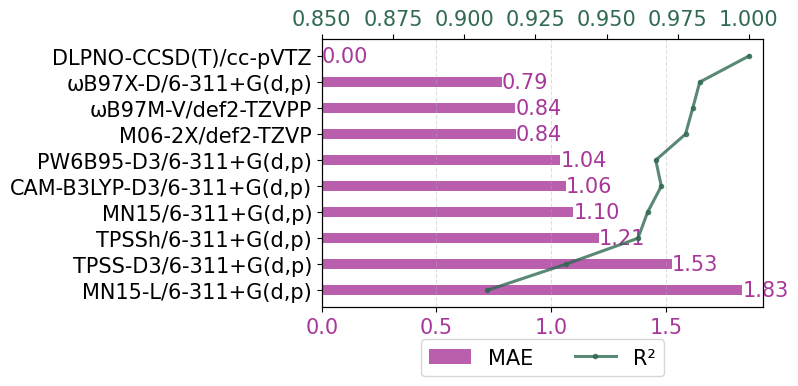

In [9]:
fig, ax_mae = plt.subplots(figsize=(8, 4))

bars = ax_mae.barh(
    plot_df["label"],
    plot_df["linear_mae"],
    color="#a8379a",
    alpha=0.8,
    height=0.38,
    label="MAE",
)
bars[-1].set_color("orange")
bars[-1].set_alpha(1.0)

ax_mae.tick_params(axis="x", labelcolor="#a8379a", labelsize=15)
ax_mae.tick_params(axis="y", labelsize=15)
ax_mae.grid(axis="x", linestyle="--", alpha=0.4)

for bar in bars:
    width = bar.get_width()
    ax_mae.text(
        width + 0.0005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=15,
        color="#a8379a",
    )

ax_r2 = ax_mae.twiny()
ax_r2.plot(
    plot_df["linear_r2"],
    plot_df["label"],
    color="#306a51",
    marker="o",
    markersize=3,
    linewidth=2.2,
    label="R²",
    alpha=0.8,
)
ax_r2.tick_params(axis="x", labelcolor="#306a51", labelsize=15)
ax_r2.set_xlim(0.85, 1.005)

lines_mae, labels_mae = ax_mae.get_legend_handles_labels()
lines_r2, labels_r2 = ax_r2.get_legend_handles_labels()
ax_mae.legend(
    lines_mae + lines_r2,
    labels_mae + labels_r2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    fontsize=15,
)

FIGURE_DIR.mkdir(exist_ok=True)
fig.tight_layout()
fig.savefig(BENCHMARK_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()


4.178754558386673 [0.82919908]


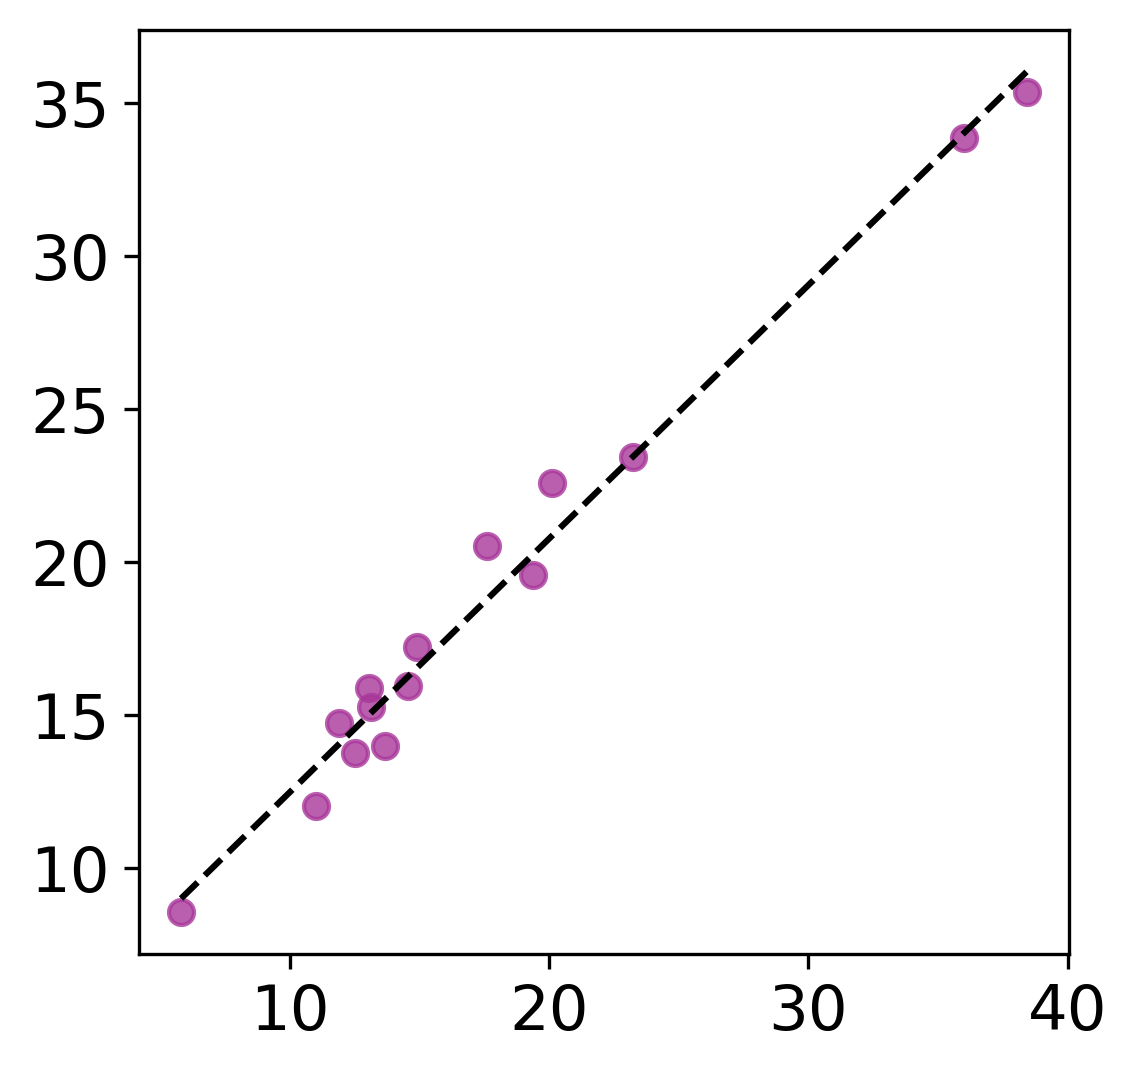

In [19]:
plt.figure(figsize=(4, 4), dpi=300)
x = benchmark_results["wB97XD"]
y = benchmark_results["DLPNO"]
model = LinearRegression().fit(x.values.reshape(-1, 1), y)
calibrated_values = model.predict(x.values.reshape(-1, 1))
print(model.intercept_, model.coef_)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.plot(
    [benchmark_results["wB97XD"].min(), benchmark_results["wB97XD"].max()],
    [calibrated_values.min(), calibrated_values.max()],
    color="black",
    linestyle="--",
    linewidth=1.5,
)
plt.scatter(
    benchmark_results["wB97XD"],
    y,
    color="#a8379a",
    alpha=0.8,
)
